# 02 - EDA si cleanup usor

Scop:
- citim datasetul din HDFS;
- eliminam coloane slab utile pentru modelare;
- tratam valori lipsa;
- calculam statistici descriptive;
- identificam outlieri pentru intarzieri;
- cream cateva grafice simple;
- salvam dataset curatat tot ca CSV in HDFS.

Nu folosim biblioteci externe peste Dockerfile: PySpark, pandas, matplotlib.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel

spark = (
    SparkSession.builder
    .appName("FlightsProject")
    .master("spark://master:7077")
    .config("spark.executor.memory", "1g")
    .config("spark.executor.cores", "1")
    .config("spark.cores.max", "2")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 11:08:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.8
Master: spark://master:7077


In [2]:
HDFS_RAW_CSV = "hdfs://master:9000/flights/raw/flights.csv"

flights = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(HDFS_RAW_CSV)
    .repartition(4)
)

print("Randuri initiale:", flights.count())
flights.printSchema()

[Stage 2:=============================>                             (1 + 1) / 2]

Randuri initiale: 336776
root
 |-- id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- sched_dep_time: integer (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- arr_time: double (nullable = true)
 |-- sched_arr_time: integer (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- carrier: string (nullable = true)
 |-- flight: integer (nullable = true)
 |-- tailnum: string (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- air_time: double (nullable = true)
 |-- distance: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- minute: integer (nullable = true)
 |-- time_hour: timestamp (nullable = true)
 |-- name: string (nullable = true)



In [3]:
# Selectie coloane utile. Pastram id daca exista, dar nu il folosim in ML.
wanted_cols = [
    "id", "year", "month", "day", "dep_time", "sched_dep_time", "dep_delay",
    "arr_time", "sched_arr_time", "arr_delay", "carrier", "flight", "tailnum",
    "origin", "dest", "air_time", "distance", "hour", "minute", "time_hour", "name"
]
existing_cols = [c for c in wanted_cols if c in flights.columns]
flights = flights.select(*existing_cols)

# Curatare usoara:
# - eliminam randurile fara tinta arr_delay;
# - eliminam randurile fara coloane esentiale;
# - inlocuim valori lipsa numerice simple cu 0 doar unde are sens operational.
required = ["arr_delay", "dep_delay", "air_time", "distance", "carrier", "origin", "dest", "month", "day", "hour"]
required = [c for c in required if c in flights.columns]

clean = flights.dropna(subset=required)

numeric_fill_zero = [c for c in ["dep_delay", "arr_delay", "air_time", "distance", "hour", "minute"] if c in clean.columns]
clean = clean.fillna(0, subset=numeric_fill_zero)

# Coloane derivate simple
clean = (
    clean
    .withColumn("is_dep_delayed", F.when(F.col("dep_delay") > 15, 1).otherwise(0))
    .withColumn("is_arr_delayed", F.when(F.col("arr_delay") > 15, 1).otherwise(0))
    .withColumn("route", F.concat_ws("-", F.col("origin"), F.col("dest")))
    .withColumn("speed_mph", F.when(F.col("air_time") > 0, F.col("distance") / (F.col("air_time") / 60.0)).otherwise(None))
)

clean = clean.persist(StorageLevel.MEMORY_AND_DISK)

print("Randuri dupa cleanup:", clean.count())
clean.show(5, truncate=False)


Randuri dupa cleanup: 327346
+------+----+-----+---+--------+--------------+---------+--------+--------------+---------+-------+------+-------+------+----+--------+--------+----+------+-------------------+-----------------+--------------+--------------+-------+------------------+
|id    |year|month|day|dep_time|sched_dep_time|dep_delay|arr_time|sched_arr_time|arr_delay|carrier|flight|tailnum|origin|dest|air_time|distance|hour|minute|time_hour          |name             |is_dep_delayed|is_arr_delayed|route  |speed_mph         |
+------+----+-----+---+--------+--------------+---------+--------+--------------+---------+-------+------+-------+------+----+--------+--------+----+------+-------------------+-----------------+--------------+--------------+-------+------------------+
|121490|2013|2    |12 |1846.0  |1846          |0.0      |2014.0  |2018          |-4.0     |B6     |130   |N184JB |JFK   |BUF |63.0    |301     |18  |46    |2013-02-12 18:00:00|JetBlue Airways  |0             |0     

In [4]:
# Statistici descriptive cerute: min, max, avg, sum, stddev, variance, skewness, kurtosis
num_cols = [c for c in ["dep_delay", "arr_delay", "air_time", "distance", "speed_mph"] if c in clean.columns]

stats_exprs = []
for c in num_cols:
    stats_exprs += [
        F.min(c).alias(f"{c}_min"),
        F.max(c).alias(f"{c}_max"),
        F.avg(c).alias(f"{c}_avg"),
        F.sum(c).alias(f"{c}_sum"),
        F.stddev(c).alias(f"{c}_stddev"),
        F.variance(c).alias(f"{c}_variance"),
        F.skewness(c).alias(f"{c}_skewness"),
        F.kurtosis(c).alias(f"{c}_kurtosis"),
    ]

stats = clean.select(*stats_exprs)
stats.show(truncate=False)


26/04/27 11:09:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 19:==============>                                           (1 + 2) / 4]

+-------------+-------------+------------------+-------------+------------------+------------------+------------------+------------------+-------------+-------------+----------------+-------------+-----------------+------------------+------------------+------------------+------------+------------+------------------+------------+-----------------+-----------------+------------------+------------------+------------+------------+------------------+------------+-----------------+-----------------+-----------------+------------------+-------------+-----------------+-----------------+-------------------+-----------------+------------------+-------------------+-------------------+
|dep_delay_min|dep_delay_max|dep_delay_avg     |dep_delay_sum|dep_delay_stddev  |dep_delay_variance|dep_delay_skewness|dep_delay_kurtosis|arr_delay_min|arr_delay_max|arr_delay_avg   |arr_delay_sum|arr_delay_stddev |arr_delay_variance|arr_delay_skewness|arr_delay_kurtosis|air_time_min|air_time_max|air_time_avg      |

In [5]:
# Outlieri dupa metoda IQR pentru arr_delay si dep_delay
for c in ["arr_delay", "dep_delay"]:
    q1, q3 = clean.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    out_count = clean.filter((F.col(c) < low) | (F.col(c) > high)).count()
    print(c, "Q1=", q1, "Q3=", q3, "low=", low, "high=", high, "outlieri=", out_count)


arr_delay Q1= -17.0 Q3= 13.0 low= -62.0 high= 58.0 outlieri= 28968
dep_delay Q1= -5.0 Q3= 10.0 low= -27.5 high= 32.5 outlieri= 45803


In [6]:
# Agregari EDA pe categorii
by_carrier = (
    clean.groupBy("carrier", "name")
    .agg(
        F.count("*").alias("flights"),
        F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay"),
        F.round(F.avg("arr_delay"), 2).alias("avg_arr_delay"),
        F.round(F.avg("distance"), 2).alias("avg_distance")
    )
    .orderBy(F.desc("flights"))
)

by_route = (
    clean.groupBy("route")
    .agg(
        F.count("*").alias("flights"),
        F.round(F.avg("arr_delay"), 2).alias("avg_arr_delay")
    )
    .orderBy(F.desc("flights"))
)

by_carrier.show(20, truncate=False)
by_route.show(20, truncate=False)


+-------+---------------------------+-------+-------------+-------------+------------+
|carrier|name                       |flights|avg_dep_delay|avg_arr_delay|avg_distance|
+-------+---------------------------+-------+-------------+-------------+------------+
|UA     |United Air Lines Inc.      |57782  |12.02        |3.56         |1531.32     |
|B6     |JetBlue Airways            |54049  |12.97        |9.46         |1069.69     |
|EV     |ExpressJet Airlines Inc.   |51108  |19.84        |15.8         |562.87      |
|DL     |Delta Air Lines Inc.       |47658  |9.22         |1.64         |1237.98     |
|AA     |American Airlines Inc.     |31947  |8.57         |0.36         |1343.28     |
|MQ     |Envoy Air                  |25037  |10.45        |10.77        |570.37      |
|US     |US Airways Inc.            |19831  |3.74         |2.13         |560.83      |
|9E     |Endeavor Air Inc.          |17294  |16.44        |7.38         |529.89      |
|WN     |Southwest Airlines Co.     |12044 

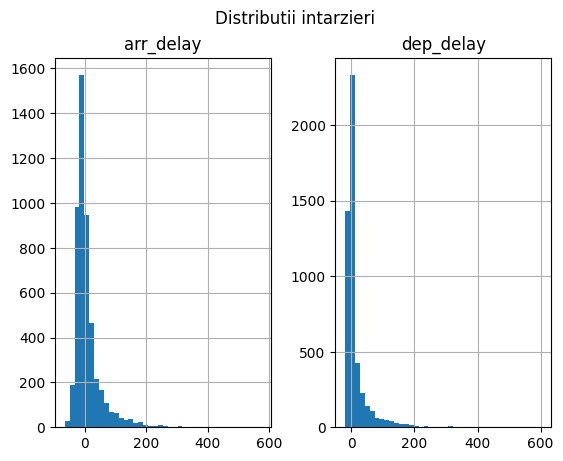

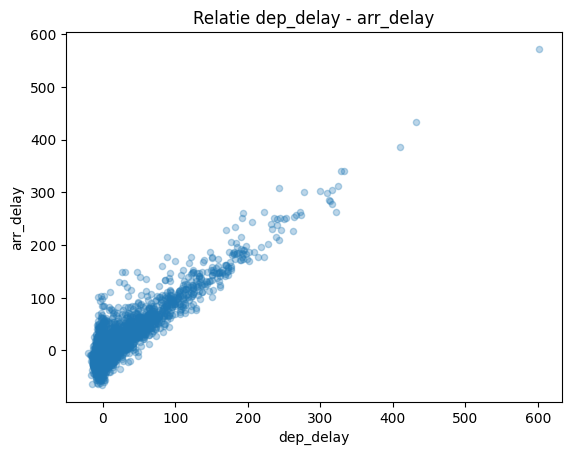

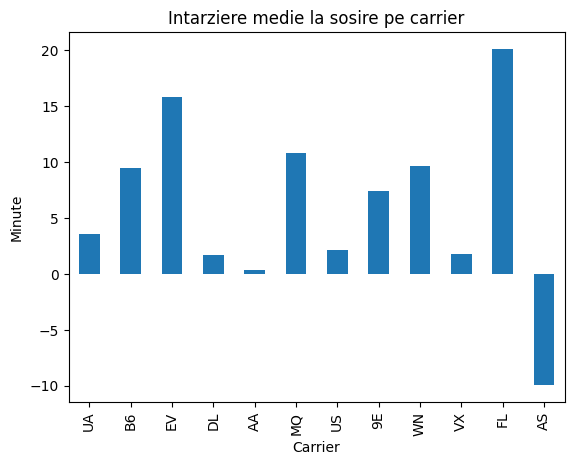

In [7]:
# Grafice simple pe sample mic ca sa nu incarcam driverul
import matplotlib.pyplot as plt

sample_pdf = (
    clean.select("arr_delay", "dep_delay", "distance", "air_time", "carrier", "month")
    .sample(False, 0.05, seed=42)
    .limit(5000)
    .toPandas()
)

sample_pdf[["arr_delay", "dep_delay"]].hist(bins=40)
plt.suptitle("Distributii intarzieri")
plt.show()

sample_pdf.plot.scatter(x="dep_delay", y="arr_delay", alpha=0.3)
plt.title("Relatie dep_delay - arr_delay")
plt.show()

carrier_pdf = by_carrier.limit(12).toPandas()
carrier_pdf.plot.bar(x="carrier", y="avg_arr_delay", legend=False)
plt.title("Intarziere medie la sosire pe carrier")
plt.xlabel("Carrier")
plt.ylabel("Minute")
plt.show()


In [8]:
# Salvam datasetul curatat in HDFS ca CSV, nu Parquet.
# Coalesce(1) e comod pentru proiect, dar poate fi lent pe date foarte mari.
OUTPUT_PATH = "hdfs://master:9000/flights/clean"


(
    clean
    .coalesce(4)
    .write
    .mode("overwrite")
    .option("header", "true")
    .csv(OUTPUT_PATH)
)

print("Dataset curatat salvat in:", OUTPUT_PATH)


[Stage 57:=============================>                            (2 + 2) / 4]

Dataset curatat salvat in: hdfs://master:9000/flights/clean


Interpretare:
- Intarzierile au de obicei distributie asimetrica: multe zboruri au intarzieri mici, dar exista outlieri mari.
- `dep_delay` este de asteptat sa fie corelat cu `arr_delay`, deoarece plecarea intarziata afecteaza sosirea.
- Agregarile pe carrier si ruta arata diferente operationale intre companii si trasee.
- Cleanup-ul este intentionat simplu: eliminare valori lipsa esentiale, coloane derivate si salvare CSV.


In [9]:
clean.unpersist()
spark.stop()
